In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

# Number of cities
num_cities = 8

# Generate random city coordinates
cities = np.random.rand(num_cities, 2) * 100

# Distance matrix
def distance_matrix(cities):
    n = len(cities)
    dist = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            dist[i][j] = np.linalg.norm(cities[i] - cities[j])
    return dist

dist = distance_matrix(cities)

In [ ]:
# ACO parameters
num_ants = 10
iterations = 50
alpha = 1
beta = 2
evaporation = 0.5
Q = 100

# Initialize pheromone
pheromone = np.ones((num_cities, num_cities))


# Build tour
def build_tour():
    tour = []
    visited = set()

    current = random.randint(0, num_cities - 1)
    tour.append(current)
    visited.add(current)

    while len(tour) < num_cities:
        probs = []

        for j in range(num_cities):
            if j not in visited:
                tau = pheromone[current][j] ** alpha
                eta = (1 / dist[current][j]) ** beta
                probs.append((j, tau * eta))

        total = sum(p for _, p in probs)
        probs = [(j, p / total) for j, p in probs]

        r = random.random()
        cumulative = 0

        for j, p in probs:
            cumulative += p
            if r <= cumulative:
                next_city = j
                break

        tour.append(next_city)
        visited.add(next_city)
        current = next_city

    return tour


# Tour length
def tour_length(tour):
    return sum(dist[tour[i]][tour[(i+1) % num_cities]] for i in range(len(tour)))

In [ ]:
best_tour = None
best_length = float('inf')

for _ in range(iterations):
    all_tours = []

    for _ in range(num_ants):
        tour = build_tour()
        length = tour_length(tour)
        all_tours.append((tour, length))

        if length < best_length:
            best_length = length
            best_tour = tour

    # Evaporation
    pheromone *= (1 - evaporation)

    # Update pheromone
    for tour, length in all_tours:
        for i in range(len(tour)):
            a = tour[i]
            b = tour[(i+1) % num_cities]
            pheromone[a][b] += Q / length

print("Best Path:", best_tour)
print("Shortest Distance:", round(best_length, 2))

Best Path: [0, 1, 2, 7, 4, 6, 5, 3]
Shortest Distance: 289.64


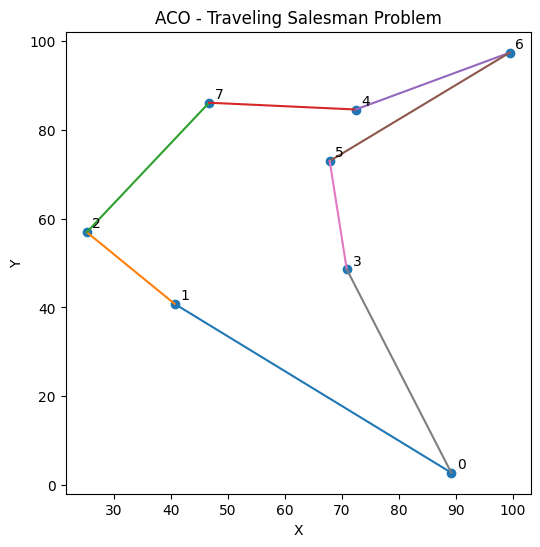

In [ ]:
x = cities[:, 0]
y = cities[:, 1]

plt.figure(figsize=(6,6))
plt.scatter(x, y)

# Draw path
for i in range(len(best_tour)):
    a = best_tour[i]
    b = best_tour[(i+1) % num_cities]

    plt.plot([cities[a][0], cities[b][0]],
             [cities[a][1], cities[b][1]])

# Label cities
for i in range(num_cities):
    plt.text(cities[i][0]+1, cities[i][1]+1, str(i))

plt.title("ACO - Traveling Salesman Problem")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()